In [ ]:
import librosa
import librosa.display
import matplotlib.pyplot as plt

Text(0, 0.5, 'Amplitude')

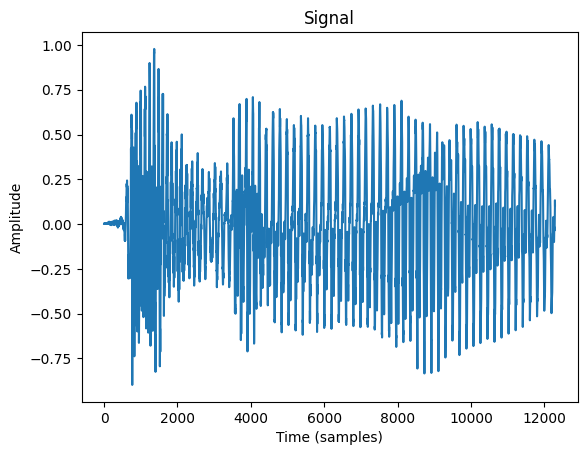

In [ ]:
y,sr = librosa.load('./hello.wav')

plt.plot(y)
plt.title('Signal')
plt.xlabel("Time (samples)")
plt.ylabel('Amplitude')

Text(0, 0.5, 'Amplitude')

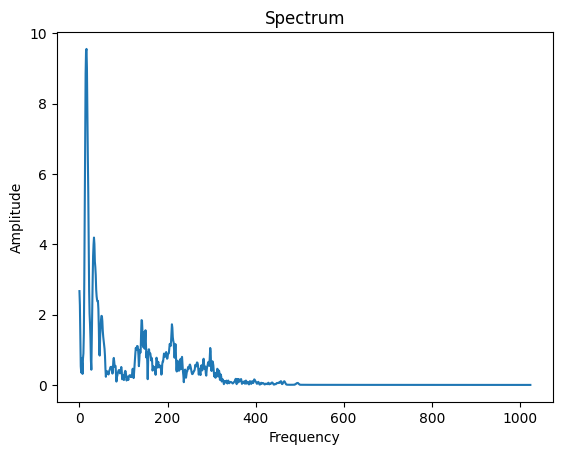

In [ ]:
import numpy as np

n_fft = 2048
ft = np.abs(librosa.stft(y[:n_fft], hop_length = n_fft+1))

plt.plot(ft)
plt.title("Spectrum")
plt.xlabel("Frequency")
plt.ylabel("Amplitude")

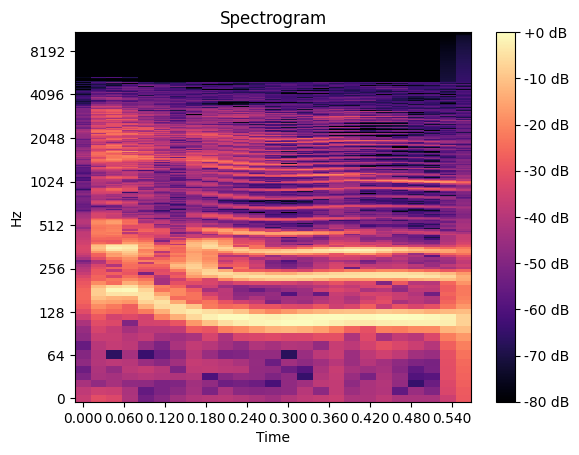

In [ ]:
spec = np.abs(librosa.stft(y, hop_length=512))
spec = librosa.amplitude_to_db(spec, ref=np.max)
librosa.display.specshow(spec, sr=sr, x_axis='time', y_axis='log');
plt.colorbar(format='%+2.0f dB');
plt.title('Spectrogram');

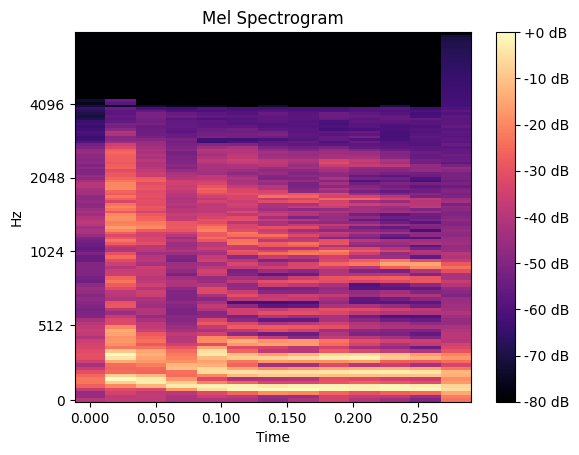

In [ ]:
mel_spect = librosa.feature.melspectrogram(
    y=y,
    sr=sr,
    n_fft=2048,
    hop_length=1024
)

mel_spect_db = librosa.power_to_db(
    mel_spect,
    ref=np.max
)

librosa.display.specshow(
    mel_spect_db,
    y_axis='mel',
    fmax=8000,
    x_axis='time'
)

plt.title('Mel Spectrogram')
plt.colorbar(format='%+2.0f dB')
plt.show()

Visualize the MFCC Features

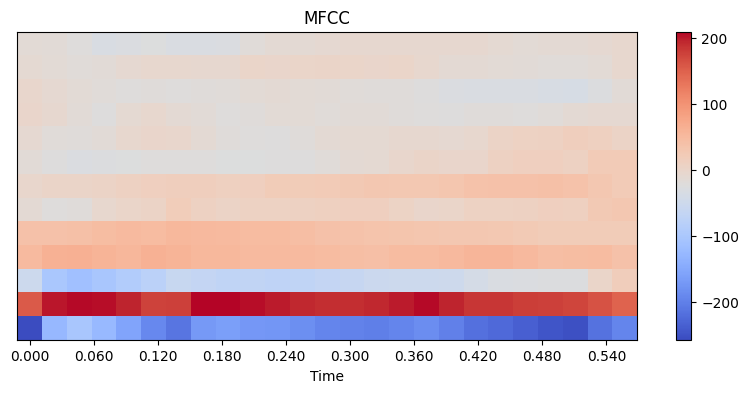

In [ ]:
mfccs = librosa.feature.mfcc(
    y=y,
    sr=sr,
    n_mfcc=13
)

plt.figure(figsize=(10,4))

librosa.display.specshow(
    mfccs,
    x_axis='time'
)

plt.colorbar()
plt.title("MFCC")
plt.show()



# the heatmap shows the MFCC feature of the audio over time
# MFCC stands for the Mel Frequency Cepstral Coefficients
# its compressed representation of speech
# x-axis shows time, so moving from left to right means going through the spoken word
# y-axis shows mfcc coefficients, there are 13 rows since n_mfcc=13
# color meaning -->  Blue-negative ; white - around 0 ; red - postive value
# These are coefficient values after DCT compression.


Plot Individual MFCC Coefficients

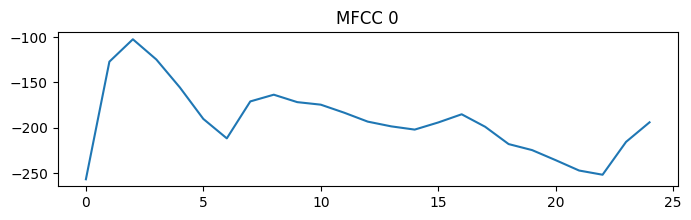

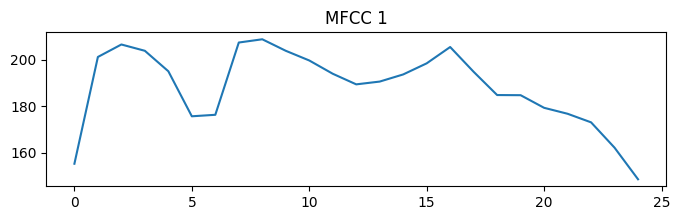

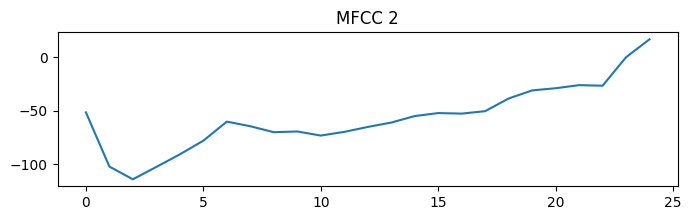

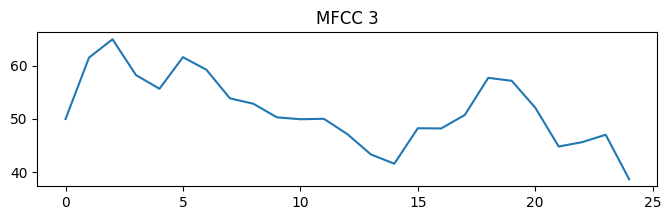

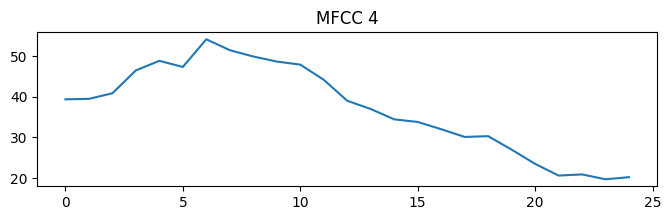

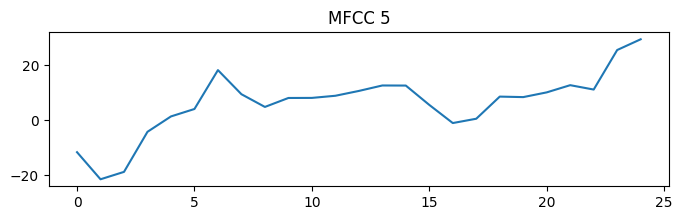

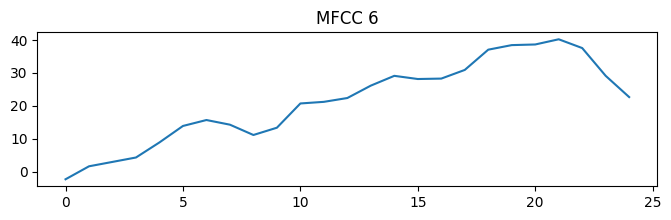

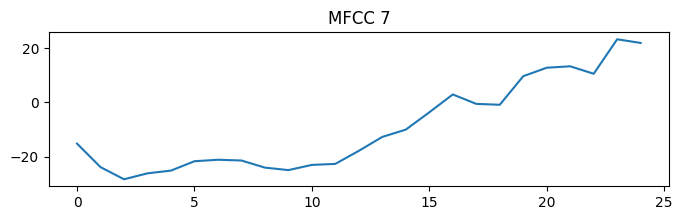

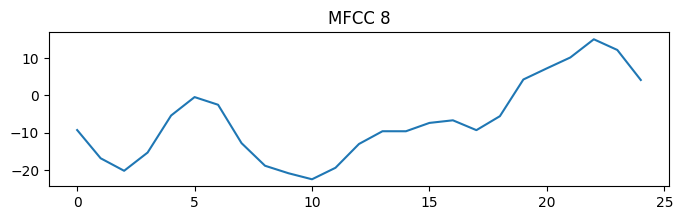

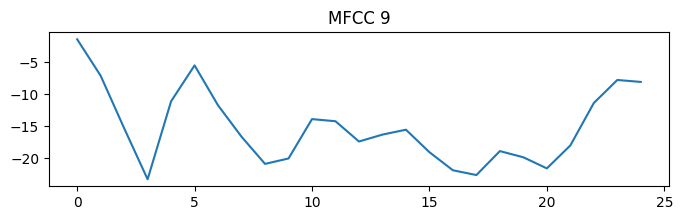

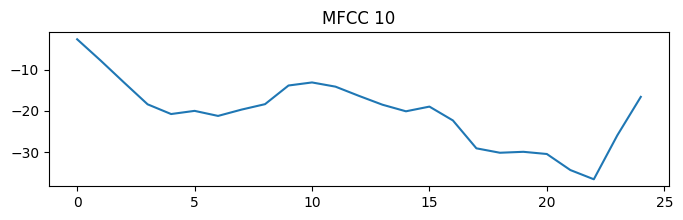

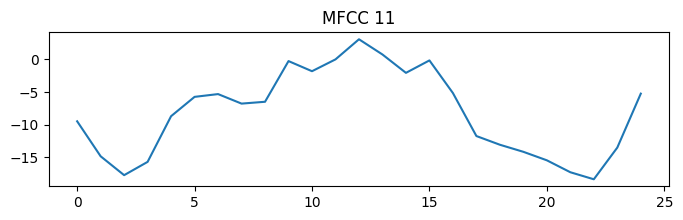

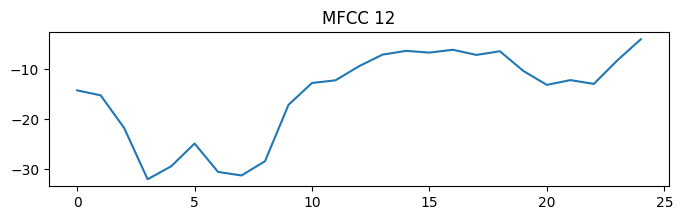

In [ ]:
for i in range(13):
    plt.figure(figsize=(8,2))
    plt.plot(mfccs[i])
    plt.title(f"MFCC {i}")
    plt.show()

Zero Crossing Rate

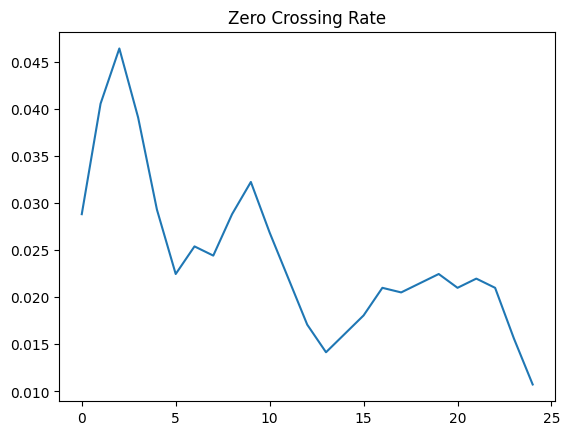

In [ ]:
# Zero Crossing Rate
# It measures how often signal changes the sign
# helps in distinguishing between the speech,music and noise

zcr = librosa.feature.zero_crossing_rate(y)

plt.plot(zcr[0])
plt.title("Zero Crossing Rate")
plt.show()


RMS Energy

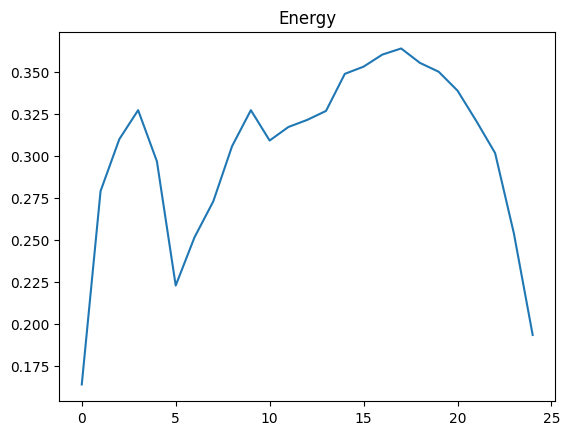

In [ ]:
rms = librosa.feature.rms(y=y)

plt.plot(rms[0])
plt.title("Energy")
plt.show()

Pitch Detection

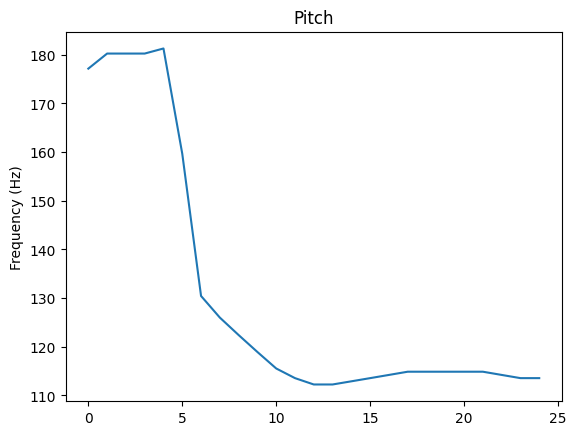

In [ ]:
f0, voiced_flag, voiced_probs = librosa.pyin(
    y,
    fmin=50,
    fmax=300
)

plt.plot(f0)
plt.title("Pitch")
plt.ylabel("Frequency (Hz)")
plt.show()


# Useful for:

# speaker analysis
# emotion detection
# singing voice analysis

Voice Activity Detection

In [ ]:
intervals = librosa.effects.split(
    y,
    top_db=20
)

print(intervals)

[[    0 12289]]
